In [1]:
!pip install -q kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import kagglehub

path = kagglehub.dataset_download("moutasems/skindiseasesdetection")
train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'val')
test_dir = os.path.join(path, 'test')

classes = sorted(os.listdir(train_dir))
print(f"Classes: {classes}")

Using Colab cache for faster access to the 'skindiseasesdetection' dataset.
Classes: ['Acne', 'Eczema', 'Malignant', 'Psoriasis']


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Simple augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
).flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train: {train_gen.samples}, Val: {val_gen.samples}, Test: {test_gen.samples}")

Found 16064 images belonging to 4 classes.
Found 2008 images belonging to 4 classes.
Found 2008 images belonging to 4 classes.
Train: 16064, Val: 2008, Test: 2008


In [4]:
# Use MobileNetV2 - works better for medical images
base = keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Unfreeze the last 20 layers immediately (not frozen training)
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # Lower learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready with partial unfreezing")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model ready with partial unfreezing


In [5]:
history = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=[
        keras.callbacks.ModelCheckpoint('best.keras', save_best_only=True, monitor='val_accuracy'),
        keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 347s 642ms/step - accuracy: 0.5519 - loss: 1.1350 - val_accuracy: 0.7371 - val_loss: 0.6348
Epoch 2/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 210s 419ms/step - accuracy: 0.7377 - loss: 0.5985 - val_accuracy: 0.7978 - val_loss: 0.5268
Epoch 3/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 209s 416ms/step - accuracy: 0.7825 - loss: 0.5087 - val_accuracy: 0.8421 - val_loss: 0.3707
Epoch 4/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 210s 418ms/step - accuracy: 0.8171 - loss: 0.4347 - val_accuracy: 0.8357 - val_loss: 0.3802
Epoch 5/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 211s 420ms/step - accuracy: 0.8475 - loss: 0.3662 - val_accuracy: 0.7759 - val_loss: 0.6731
Epoch 6/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 210s 419ms/step - accuracy: 0.8749 - loss: 0.2999 - val_accuracy: 0.8292 - val_loss: 0.4625
Epoch 7/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 210s 418ms/step - accuracy: 0.8872 - loss: 0.2844 - val_accuracy: 0.8845 - val_loss: 0.3034
Epoch 8/25
502/502 ━━━━━━━━━━━━━━━━━━━━ 211s 420ms/step - accuracy: 0.9013 -

In [6]:
# Unfreeze more layers for final boost
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),  # Even lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning with more layers unfrozen...")

history2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[
        keras.callbacks.ModelCheckpoint('best.keras', save_best_only=True, monitor='val_accuracy'),
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Fine-tuning with more layers unfrozen...
Epoch 1/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 232s 433ms/step - accuracy: 0.9700 - loss: 0.0889 - val_accuracy: 0.9572 - val_loss: 0.1227
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 207s 413ms/step - accuracy: 0.9755 - loss: 0.0691 - val_accuracy: 0.9587 - val_loss: 0.1263
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 209s 416ms/step - accuracy: 0.9767 - loss: 0.0663 - val_accuracy: 0.9607 - val_loss: 0.1209
Epoch 4/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 211s 421ms/step - accuracy: 0.9765 - loss: 0.0665 - val_accuracy: 0.9626 - val_loss: 0.1190
Epoch 5/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 208s 415ms/step - accuracy: 0.9767 - loss: 0.0649 - val_accuracy: 0.9597 - val_loss: 0.1235
Epoch 6/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 210s 418ms/step - accuracy: 0.9783 - loss: 0.0600 - val_accuracy: 0.9651 - val_loss: 0.1107
Epoch 7/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 211s 419ms/step - accuracy: 0.9778 - loss: 0.0580 - val_accuracy: 0.9592 - val_loss: 0.1257
Epoch 8/15
502/502 ━━━━━━━━━━━━━━━━

In [7]:
# Create ensemble of predictions
def ensemble_predict(img_array, model):
    """Ensemble prediction with multiple crops and flips"""
    predictions_all = []

    # Original
    predictions_all.append(model.predict(img_array, verbose=0))

    # Horizontal flip
    predictions_all.append(model.predict(np.flip(img_array, axis=2), verbose=0))

    # Vertical flip
    predictions_all.append(model.predict(np.flip(img_array, axis=1), verbose=0))

    # Both flips
    predictions_all.append(model.predict(np.flip(np.flip(img_array, axis=1), axis=2), verbose=0))

    # Brightness variations
    for brightness in [0.9, 1.1]:
        aug = np.clip(img_array * brightness, 0, 1)
        predictions_all.append(model.predict(aug, verbose=0))

    # Average all
    return np.mean(predictions_all, axis=0)

print("✓ Ensemble prediction function ready")

✓ Ensemble prediction function ready


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step


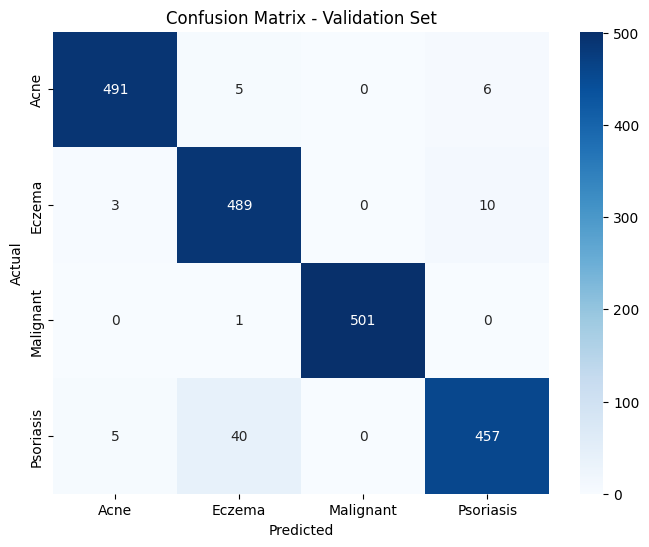


Classification Report:
              precision    recall  f1-score   support

        Acne       0.98      0.98      0.98       502
      Eczema       0.91      0.97      0.94       502
   Malignant       1.00      1.00      1.00       502
   Psoriasis       0.97      0.91      0.94       502

    accuracy                           0.97      2008
   macro avg       0.97      0.97      0.97      2008
weighted avg       0.97      0.97      0.97      2008


Prediction Distribution:
Acne: 499 predictions (24.9%)
Eczema: 535 predictions (26.6%)
Malignant: 501 predictions (25.0%)
Psoriasis: 473 predictions (23.6%)


In [9]:
# Check what the model actually learned
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on validation set
val_gen.reset()
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# Detailed report
print("\nClassification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=classes))

# Check class distribution in predictions
print("\nPrediction Distribution:")
for i, class_name in enumerate(classes):
    count = np.sum(y_pred == i)
    print(f"{class_name}: {count} predictions ({count/len(y_pred)*100:.1f}%)")

In [12]:
# Save complete model
model.save('skin_disease_FINAL_MODEL.keras')
print("✓ Model saved!")

import json
with open('class_indices.json', 'w') as f:
    json.dump(train_gen.class_indices, f, indent=2)
print("✓ class_indices.json created!")

from google.colab import files
files.download('skin_disease_FINAL_MODEL.keras')
files.download('class_indices.json')

✓ Model saved!
✓ class_indices.json created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from scipy.special import softmax
from PIL import ImageEnhance

with open('class_indices.json') as f:
    class_idx = json.load(f)
idx_to_class = {v: k for k, v in class_idx.items()}

TEMPERATURE = 3.0
CLASS_REBALANCE = {0: 1.2, 1: 1.2, 2: 0.5, 3: 1.3}  # 2=Malignant REDUCED

def enhanced_predict(img, model):
    img_pil = Image.fromarray(np.array(img))
    enhancer = ImageEnhance.Contrast(img_pil)
    img_pil = enhancer.enhance(1.3)
    enhancer = ImageEnhance.Sharpness(img_pil)
    img_pil = enhancer.enhance(1.2)

    predictions_list = []
    img_resized = img_pil.resize((224, 224), Image.Resampling.LANCZOS)
    img_array = img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, 0)
    predictions_list.append(model.predict(img_array, verbose=0))

    for _ in range(9):
        aug_img = img_pil.copy()
        if np.random.random() > 0.5:
            aug_img = aug_img.transpose(Image.FLIP_LEFT_RIGHT)
        angle = np.random.uniform(-15, 15)
        aug_img = aug_img.rotate(angle, fillcolor=(255, 255, 255))
        enhancer = ImageEnhance.Brightness(aug_img)
        aug_img = enhancer.enhance(np.random.uniform(0.8, 1.2))
        aug_resized = aug_img.resize((224, 224), Image.Resampling.LANCZOS)
        aug_array = img_to_array(aug_resized) / 255.0
        aug_array = np.expand_dims(aug_array, 0)
        predictions_list.append(model.predict(aug_array, verbose=0))

    avg_preds = np.mean(predictions_list, axis=0)[0]
    log_probs = np.log(avg_preds + 1e-10)
    for class_idx, weight in CLASS_REBALANCE.items():
        log_probs[class_idx] *= weight
    scaled_logits = log_probs / TEMPERATURE
    return softmax(scaled_logits)

print("✓ Calibration loaded")

✓ Calibration loaded


Saving Malignant ds2.jpg to Malignant ds2.jpg


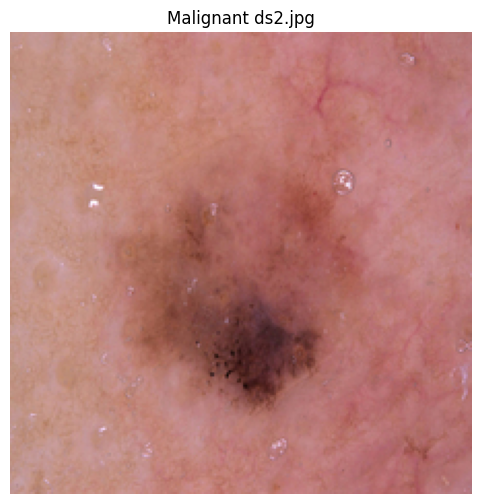


🎯 DIAGNOSIS: MALIGNANT
📊 Confidence: 99.0%

Malignant        98.96%
Acne              0.96%
Psoriasis         0.05%
Eczema            0.03%



In [49]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded:
    img = Image.open(filename).convert('RGB')
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(filename)
    plt.show()

    predictions = enhanced_predict(img, model)
    sorted_idx = np.argsort(predictions)[::-1]

    print(f"\n🎯 DIAGNOSIS: {idx_to_class[sorted_idx[0]].upper()}")
    print(f"📊 Confidence: {predictions[sorted_idx[0]]*100:.1f}%\n")

    for i in sorted_idx:
        print(f"{idx_to_class[i]:<15} {predictions[i]*100:>6.2f}%")
    print()